# Define variables

In [ ]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3' # disable tensorflow cuda warning messages

root_dir = './'
dataset_dir = os.path.join(root_dir, 'datasets')
dataset_dir_noisy = os.path.join(dataset_dir, 'normal')
dataset_dir_clean = os.path.join(dataset_dir, 'delay')

features_path_clean = os.path.join(dataset_dir, 'features-clean.npz')
features_path_noisy = os.path.join(dataset_dir, 'features-noisy.npz')
features_path_mixed = os.path.join(dataset_dir, 'features-mixed.npz')

model_dir = os.path.join(root_dir, 'models')
os.makedirs(model_dir, exist_ok=True)

cnn_model_path_clean = os.path.join(model_dir, 'cnn_model-clean')
cnn_model_path_noisy = os.path.join(model_dir, 'cnn_model-noisy')
cnn_model_path_mixed = os.path.join(model_dir, 'cnn_model-mixed')

svm_model_dir = os.path.join(model_dir, 'svm_model')
os.makedirs(svm_model_dir, exist_ok=True)

svm_model_path = os.path.join(svm_model_dir, 'model.pkl')
svm_scaler_path = os.path.join(svm_model_dir, 'scaler.pkl')
svm_encoder_path = os.path.join(svm_model_dir, 'label_encoder.pkl')

# CQT Feature Extraction



## Clean dataset

In [ ]:
import warnings
from tqdm.notebook import tqdm
import numpy as np
import os # Import os for path manipulation
import librosa # Keep librosa import for potential future use or if file doesn't exist

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

features = []
labels = []

# Define the path to the .npz file
save_path = features_path_clean

## Sample rate 48 khz * 2 seconds / 512 default hop size = 187.5
## Try 150 for 1.5 seconds
max_cqt_pad_len = 200

# pad -1 and +1 octave from root C4
fmin = librosa.note_to_hz('C3')

# 3 octaves in total
n_bins = 12 * 3

# default hop_length 512
hop_length = 512

def preprocess(cqt):
  if cqt.shape[1] < max_cqt_pad_len:
      pad_width = max_cqt_pad_len - cqt.shape[1]
      cqt = np.pad(cqt, pad_width=((0, 0), (0, pad_width)), mode='constant')
  else:
      cqt = cqt[:, :max_cqt_pad_len]
  return cqt

def extract_cqt_features(audio_path, fmin, n_bins, max_cqt_pad_len):
    """Extracts CQT features from an audio file."""
    try:
        y, sr = librosa.load(audio_path, sr=None)
        cqt = librosa.cqt(y=y, sr=sr, fmin=fmin, n_bins=n_bins, bins_per_octave=12, hop_length=hop_length)
        cqt = np.abs(cqt)
        return preprocess(cqt)
    except Exception as e:
        print(f"Error processing {audio_path}: {e}")
        return None

# Check if the .npz file already exists
if os.path.exists(save_path):
    print(f"Loading features and labels from {save_path}")
    data = np.load(save_path)
    features = np.array([preprocess(f) for f in data['features']])
    labels = data['labels']
    print("Features and labels loaded successfully.")
else:
    features = []
    labels = []
    dataset_path = dataset_dir_clean

    for class_name in tqdm(os.listdir(dataset_path), desc="Processing classes"):
        class_path = os.path.join(dataset_path, class_name)
        if os.path.isdir(class_path):
            for audio_file in tqdm(os.listdir(class_path), desc=f"Processing {class_name}"):
                audio_path = os.path.join(class_path, audio_file)
                if os.path.isfile(audio_path):
                    cqt_features = extract_cqt_features(audio_path, fmin, n_bins, max_cqt_pad_len)
                    if cqt_features is not None:
                        features.append(cqt_features)
                        labels.append(class_name)

    features = np.array(features)
    labels = np.array(labels)

    print(f"Shape of CQT features: {features.shape}")
    print(f"Shape of CQT labels: {labels.shape}")
    
    # Save the features and labels
    np.savez(save_path, features=features, labels=labels)

    print(f"Features and labels saved to {save_path}")

Loading features and labels from ./datasets/features-clean.npz
Features and labels loaded successfully.


## Noisy dataset

In [ ]:
import warnings
from tqdm.notebook import tqdm
import numpy as np
import os # Import os for path manipulation
import librosa # Keep librosa import for potential future use or if file doesn't exist

noisy_features = []
noisy_labels = []

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

# Define the path to the .npz file
save_path = features_path_noisy

print(f"Features and labels not found at {save_path}. Processing audio files...")

## Sample rate 48 khz * 2 seconds / 512 default hop size = 187.5
## Try 150 for 1.5 seconds
max_cqt_pad_len = 200

# pad -1 and +1 octave from root C4
fmin = librosa.note_to_hz('C3')

# 3 octaves in total
n_bins = 12 * 3

# default hop_length 512
hop_length = 512

def preprocess(cqt):
  if cqt.shape[1] < max_cqt_pad_len:
      pad_width = max_cqt_pad_len - cqt.shape[1]
      cqt = np.pad(cqt, pad_width=((0, 0), (0, pad_width)), mode='constant')
  else:
      cqt = cqt[:, :max_cqt_pad_len]
  return cqt

def extract_cqt_features(audio_path, fmin, n_bins, max_cqt_pad_len):
    """Extracts CQT features from an audio file."""
    try:
        y, sr = librosa.load(audio_path, sr=None)
        cqt = librosa.cqt(y=y, sr=sr, fmin=fmin, n_bins=n_bins, bins_per_octave=12, hop_length=hop_length)
        cqt = np.abs(cqt)
        return preprocess(cqt)
    except Exception as e:
        print(f"Error processing {audio_path}: {e}")
        return None

# Check if the .npz file already exists
if os.path.exists(save_path):
    print(f"Loading features and labels from {save_path}")
    data = np.load(save_path)
    noisy_features = np.array([preprocess(f) for f in data['features']])
    noisy_labels = data['labels']
    print("Features and labels loaded successfully.")
else:
    dataset_path = dataset_dir_noisy

    for class_name in tqdm(os.listdir(dataset_path), desc="Processing classes"):
        class_path = os.path.join(dataset_path, class_name)
        if os.path.isdir(class_path):
            for audio_file in tqdm(os.listdir(class_path), desc=f"Processing {class_name}"):
                audio_path = os.path.join(class_path, audio_file)
                if os.path.isfile(audio_path):
                    cqt_features = extract_cqt_features(audio_path, fmin, n_bins, max_cqt_pad_len)
                    if cqt_features is not None:
                        noisy_features.append(cqt_features)
                        noisy_labels.append(class_name)

    noisy_features = np.array(noisy_features)
    noisy_labels = np.array(noisy_labels)

    print(f"Shape of CQT features: {noisy_features.shape}")
    print(f"Shape of CQT labels: {noisy_labels.shape}")

    # Save the features and labels
    np.savez(save_path, features=noisy_features, labels=noisy_labels)

    print(f"Features and labels saved to {save_path}")

Features and labels not found at ./datasets/features-noisy.npz. Processing audio files...
Loading features and labels from ./datasets/features-noisy.npz
Features and labels loaded successfully.


## Inspect features

In [ ]:
import audioread
import os

# Select a sample audio file (replace with a path from your dataset)
sample_audio_path = os.path.join(dataset_dir_clean, 'C_major_4', 'C_major_4-1.wav') # Using the first file of the first class as an example

# Open the audio file to get its info
try:
    with audioread.audio_open(sample_audio_path) as f:
        print(f"Audio File: {sample_audio_path}")
        print(f"  Duration: {f.duration} seconds")
        print(f"  Sample Rate: {f.samplerate}")
        print(f"  Channels: {f.channels}")

except audioread.NoBackendError:
    print("Could not open audio file. Please ensure you have necessary backend libraries installed (e.g., ffmpeg, gstreamer).")
except Exception as e:
    print(f"Error reading audio file info: {e}")

Audio File: ./datasets/delay/C_major_4/C_major_4-1.wav
  Duration: 2.5 seconds
  Sample Rate: 48000
  Channels: 1


### Feature as spectrogram

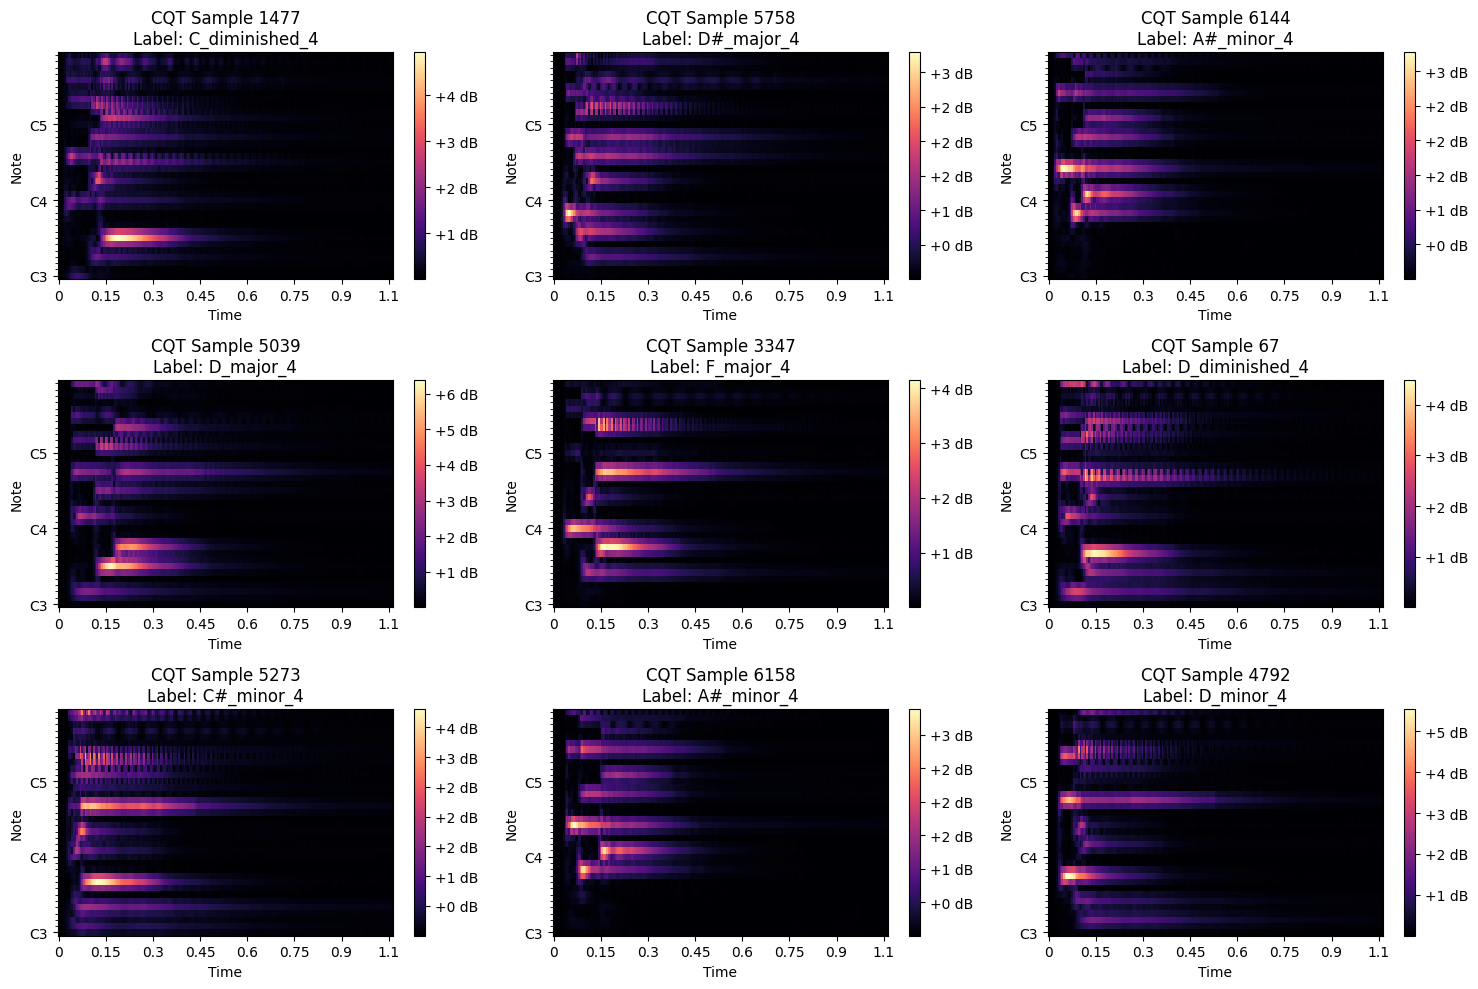

In [ ]:
import random
import matplotlib.pyplot as plt
import librosa.display

# Select 9 random indices
random_indices = random.sample(range(len(features)), min(9, len(features)))
sr = 48_000

# Plot the CQT data for the selected samples
plt.figure(figsize=(15, 10))
for i, idx in enumerate(random_indices):
    plt.subplot(3, 3, i + 1)
    # Assuming 'sr' is still available from the previous processing step
    try:
        # Explicitly pass fmin to specshow
        librosa.display.specshow(features[idx], x_axis='time', y_axis='cqt_note', sr=sr, bins_per_octave=12, fmin=fmin, hop_length=hop_length/2)
    except NameError:
        # Handle case where sr is not defined (e.g., if the previous cell failed)
        librosa.display.specshow(features[idx], x_axis='time', y_axis='cqt_note', bins_per_octave=12, fmin=fmin, hop_length=hop_length/2) # Plot without sr

    plt.colorbar(format='%+2.0f dB')
    plt.title(f'CQT Sample {idx+1}\nLabel: {labels[idx]}')

plt.tight_layout()
plt.show()

### Feature as data frame

Label: C#_diminished_4
Shape: (36, 200)
Data type: float32
Min value: 0.0000
Max value: 2.9998


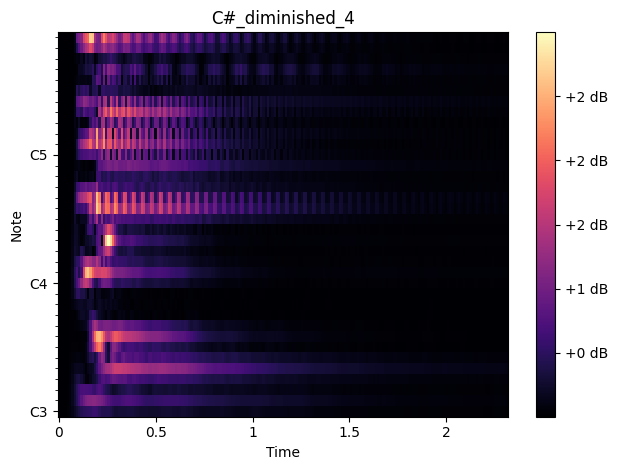

,Frame_1,Frame_2,Frame_3,Frame_4,Frame_5,Frame_6,Frame_7,Frame_8,Frame_9,Frame_10,...,Frame_191,Frame_192,Frame_193,Frame_194,Frame_195,Frame_196,Frame_197,Frame_198,Frame_199,Frame_200
C3,0.000219,0.000713,0.001736,0.005678,0.024091,0.060791,0.120547,0.193932,0.276128,0.357589,...,0.016304,0.012989,0.019223,0.029159,0.037178,0.039888,0.036822,0.030514,0.024080,0.020013
C♯3,0.000217,0.000333,0.001091,0.004579,0.021861,0.068556,0.156204,0.285468,0.448859,0.627838,...,0.046346,0.047669,0.051358,0.056351,0.061282,0.064512,0.065143,0.063687,0.060865,0.057447
D3,0.000535,0.000762,0.000869,0.002408,0.017752,0.065357,0.160501,0.300790,0.460711,0.601963,...,0.022830,0.021348,0.026722,0.032650,0.035777,0.038463,0.039666,0.036347,0.031427,0.031804
D♯3,0.000634,0.000773,0.000923,0.001274,0.010768,0.051669,0.134992,0.243353,0.331863,0.351728,...,0.055081,0.053529,0.052885,0.057481,0.063443,0.061735,0.052942,0.048215,0.050169,0.049991
E3,0.000599,0.000718,0.000525,0.000311,0.007540,0.038702,0.096150,0.156273,0.184960,0.175691,...,0.116868,0.114863,0.114995,0.115345,0.113799,0.112411,0.111863,0.109327,0.105776,0.105089
F3,0.000447,0.000603,0.000952,0.001301,0.005089,0.027616,0.059439,0.077512,0.087800,0.092165,...,0.061321,0.058527,0.057223,0.057040,0.056917,0.055915,0.055519,0.057083,0.057659,0.054917
F♯3,0.000230,0.000285,0.001380,0.001321,0.001935,0.018030,0.030183,0.032076,0.028292,0.017518,...,0.005088,0.006362,0.005241,0.007647,0.008113,0.005627,0.006352,0.007130,0.003426,0.001824
G3,0.000266,0.000596,0.001049,0.000964,0.004209,0.014316,0.021815,0.016378,0.004454,0.013713,...,0.010400,0.009907,0.008946,0.007997,0.009280,0.011503,0.011046,0.008778,0.007461,0.005989
G♯3,0.000383,0.000942,0.000186,0.002117,0.004251,0.012708,0.018844,0.035720,0.053002,0.069352,...,0.010936,0.008634,0.005556,0.002871,0.008005,0.008981,0.008920,0.005531,0.001949,0.002889
A3,0.000634,0.000325,0.000922,0.000836,0.002813,0.022754,0.018453,0.010671,0.063934,0.143398,...,0.002773,0.005915,0.006717,0.005692,0.005123,0.005237,0.004833,0.003529,0.001708,0.000363


In [ ]:
import pandas as pd

# 1. Grab sample feature and label
sample_idx = random.randint(0, len(features))
sample_feature = features[sample_idx] 
sample_label = labels[sample_idx]

print(f"Label: {sample_label}")
print(f"Shape: {sample_feature.shape}")
print(f"Data type: {sample_feature.dtype}")
print(f"Min value: {np.min(sample_feature):.4f}")
print(f"Max value: {np.max(sample_feature):.4f}")

# 2. Generate the exact frequencies for your 36 bins
# Make sure 'fmin' matches the variable you used when creating the CQT!
frequencies = librosa.cqt_frequencies(
    n_bins=sample_feature.shape[0], 
    fmin=fmin, 
    bins_per_octave=12 
)

# 3. Convert those frequencies to musical note names (e.g., 'C4', 'D#4')
note_headers = librosa.hz_to_note(frequencies)

# 4. Create column headers for the time frames
column_headers = [f"Frame_{i+1}" for i in range(sample_feature.shape[1])]

# 3. Convert the 2D numpy array into a Pandas DataFrame
df = pd.DataFrame(sample_feature, columns=column_headers, index=note_headers)

librosa.display.specshow(sample_feature, x_axis='time', y_axis='cqt_note', bins_per_octave=12, fmin=fmin, hop_length=hop_length/2)
plt.colorbar(format='%+2.0f dB')
plt.title(sample_label)
plt.tight_layout()
plt.show()

df

# CNN model

## Define constants

In [ ]:
CNN_RANDOM_STATE = 42
CNN_VALIDATION_SPLIT = 0.1
CNN_TEST_SIZE = 0.1
CNN_EPOCHS = 30
CNN_BATCH_SIZE = 32

## Single model

### Split data


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from keras.utils import to_categorical

# Encode labels
label_encoder = LabelEncoder()
encoded_labels = label_encoder.fit_transform(labels)
categorical_labels = to_categorical(encoded_labels)

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    features,
    categorical_labels,
    test_size=CNN_TEST_SIZE,
    random_state=CNN_RANDOM_STATE,
    stratify=categorical_labels
)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")
print(f"Length of training set: {len(X_train)}")
print(f"Length of testing set: {len(X_test)}")

Shape of X_train: (6480, 36, 200)
Shape of X_test: (720, 36, 200)
Shape of y_train: (6480, 36)
Shape of y_test: (720, 36)
Length of training set: 6480
Length of testing set: 720


### Build model


In [ ]:
import tensorflow as tf
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

# Get input shape and number of classes
input_shape = (features.shape[1], features.shape[2], 1) # Add channel dimension based on original features shape
num_classes = y_train.shape[1]

# Build the CNN model
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=input_shape),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(64, activation='relu'),
    Dropout(0.5),
    Dense(num_classes, activation='softmax')
])

# Compile the model
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 34, 198, 32)       320       
                                                                 
 max_pooling2d (MaxPooling2  (None, 17, 99, 32)        0         
 D)                                                              
                                                                 
 conv2d_1 (Conv2D)           (None, 15, 97, 64)        18496     
                                                                 
 max_pooling2d_1 (MaxPoolin  (None, 7, 48, 64)         0         
 g2D)                                                            
                                                                 
 flatten (Flatten)           (None, 21504)             0         
                                                                 
 dense (Dense)               (None, 64)                1

### Train model

In [ ]:
# Train the model
history = model.fit(X_train, y_train, epochs=CNN_EPOCHS, batch_size=CNN_BATCH_SIZE, validation_split=CNN_VALIDATION_SPLIT)

Epoch 1/30


I0000 00:00:1772363058.915382  208891 device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


183/183 [==============================] - 5s 11ms/step - loss: 1.7522 - accuracy: 0.4727 - val_loss: 0.0643 - val_accuracy: 1.0000
Epoch 2/30
183/183 [==============================] - 1s 8ms/step - loss: 0.6417 - accuracy: 0.7702 - val_loss: 0.0114 - val_accuracy: 1.0000
Epoch 3/30
183/183 [==============================] - 1s 8ms/step - loss: 0.4888 - accuracy: 0.8222 - val_loss: 0.0042 - val_accuracy: 1.0000
Epoch 4/30
183/183 [==============================] - 1s 8ms/step - loss: 0.4356 - accuracy: 0.8330 - val_loss: 0.0014 - val_accuracy: 1.0000
Epoch 5/30
183/183 [==============================] - 1s 8ms/step - loss: 0.3948 - accuracy: 0.8486 - val_loss: 6.9014e-04 - val_accuracy: 1.0000
Epoch 6/30
183/183 [==============================] - 1s 8ms/step - loss: 0.3799 - accuracy: 0.8539 - val_loss: 4.6951e-04 - val_accuracy: 1.0000
Epoch 7/30
183/183 [==============================] - 1s 8ms/step - loss: 0.3743 - accuracy: 0.8568 - val_loss: 2.0766e-04 - val_accuracy: 1.0000
Epoc

### Class distribution

In [ ]:

from collections import Counter
import numpy as np

import matplotlib.pyplot as plt

# Keras validation_split takes the last fraction of training data
val_size = int(len(y_train) * CNN_VALIDATION_SPLIT)
y_train_actual = y_train[:-val_size]
y_val          = y_train[-val_size:]

# Get class distribution for train, validation, and test sets
train_dist = Counter(np.argmax(y_train_actual, axis=1))
val_dist   = Counter(np.argmax(y_val,          axis=1))
test_dist  = Counter(np.argmax(y_test,         axis=1))

class_names = label_encoder.classes_
x = np.arange(len(class_names))
width = 0.4

train_counts = [train_dist.get(i, 0) for i in range(len(class_names))]
val_counts   = [val_dist.get(i, 0)   for i in range(len(class_names))]
test_counts  = [test_dist.get(i, 0)  for i in range(len(class_names))]

# Print summary table
print(f"\n{'Class':<20} {'Train':>8} {'Val':>8} {'Test':>8} {'Total':>8}")
print("-" * 56)
for i, name in enumerate(class_names):
  tr = train_dist.get(i, 0)
  vl = val_dist.get(i, 0)
  te = test_dist.get(i, 0)
  print(f"{name:<20} {tr:>8} {vl:>8} {te:>8} {tr+vl+te:>8}")
print("-" * 56)
print(f"{'TOTAL':<20} {sum(train_counts):>8} {sum(val_counts):>8} {sum(test_counts):>8} {sum(train_counts)+sum(val_counts)+sum(test_counts):>8}")



Class                   Train      Val     Test    Total
--------------------------------------------------------
A#_diminished_4           166       14       20      200
A#_major_4                167       13       20      200
A#_minor_4                162       18       20      200
A_diminished_4            166       14       20      200
A_major_4                 155       25       20      200
A_minor_4                 160       20       20      200
B_diminished_4            160       20       20      200
B_major_4                 162       18       20      200
B_minor_4                 164       16       20      200
C#_diminished_4           165       15       20      200
C#_major_4                168       12       20      200
C#_minor_4                166       14       20      200
C_diminished_4            157       23       20      200
C_major_4                 156       24       20      200
C_minor_4                 158       22       20      200
D#_diminished_4           162 

### Training history

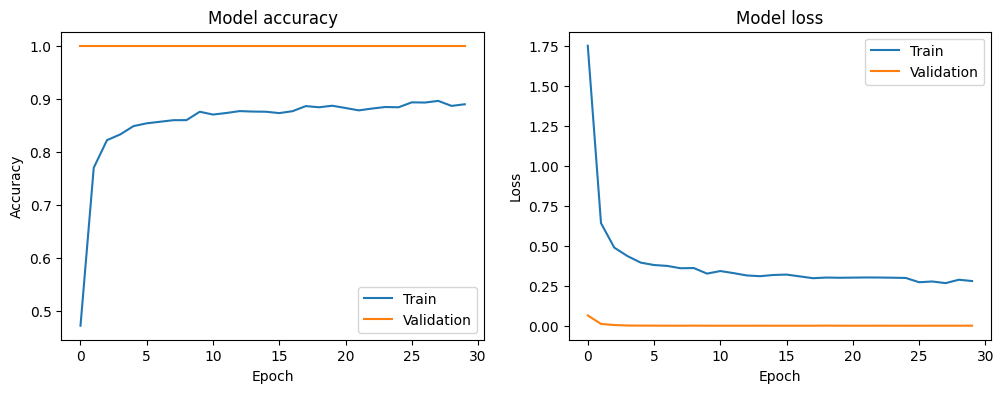

In [ ]:
import matplotlib.pyplot as plt

# Plot training & validation accuracy values
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='lower right')

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper right')

plt.show()

### Confusion Matrix

23/23 [==============================] - 0s 8ms/step


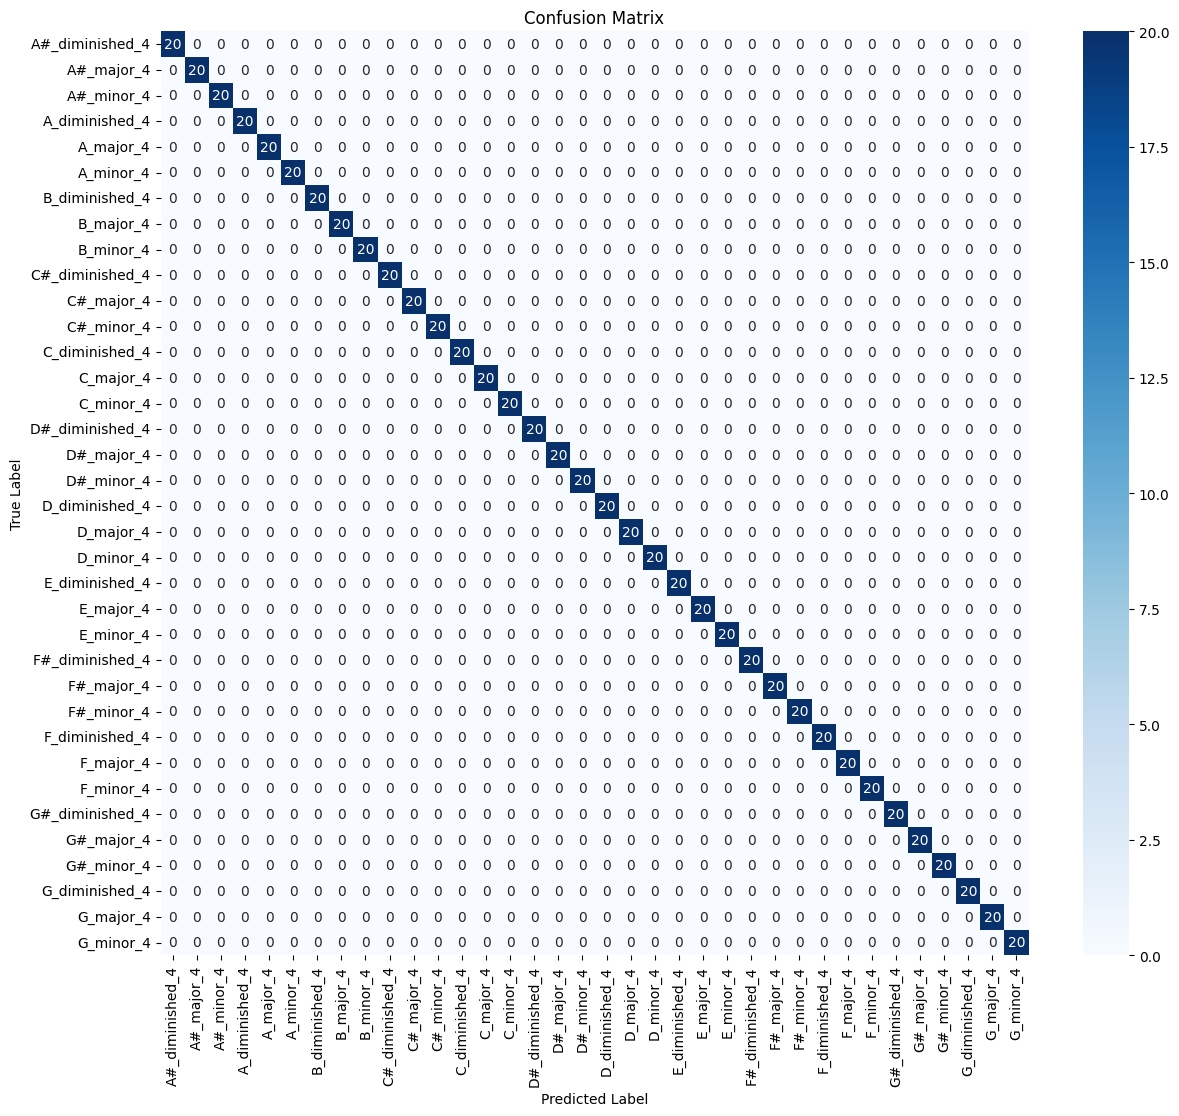

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Get predictions for the test set
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(y_test, axis=1)

# Get class labels from the label encoder
class_labels = label_encoder.classes_

# Compute the confusion matrix
cm = confusion_matrix(y_true_classes, y_pred_classes)

# Plot the confusion matrix
plt.figure(figsize=(14, 12))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

In [ ]:
from sklearn.metrics import classification_report

# Evaluate the model on the test set
loss, accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Accuracy: {accuracy}")
print(f"Test Loss: {loss}")

# Generate classification report
report = classification_report(y_true_classes, y_pred_classes, target_names=class_labels)
print("Classification Report:\n", report)

Test Accuracy: 1.0
Test Loss: 0.00015683604578953236
Classification Report:
                  precision    recall  f1-score   support

A#_diminished_4       1.00      1.00      1.00        20
     A#_major_4       1.00      1.00      1.00        20
     A#_minor_4       1.00      1.00      1.00        20
 A_diminished_4       1.00      1.00      1.00        20
      A_major_4       1.00      1.00      1.00        20
      A_minor_4       1.00      1.00      1.00        20
 B_diminished_4       1.00      1.00      1.00        20
      B_major_4       1.00      1.00      1.00        20
      B_minor_4       1.00      1.00      1.00        20
C#_diminished_4       1.00      1.00      1.00        20
     C#_major_4       1.00      1.00      1.00        20
     C#_minor_4       1.00      1.00      1.00        20
 C_diminished_4       1.00      1.00      1.00        20
      C_major_4       1.00      1.00      1.00        20
      C_minor_4       1.00      1.00      1.00        20
D#_diminis

### Save Model

In [ ]:
# Save the model
model.save(cnn_model_path_clean + '.h5')
print(f"Model saved to {cnn_model_path_clean}.h5")

Model saved to ./models/cnn_model-clean.h5


### Test Model

In [ ]:
import random
import tensorflow as tf
import numpy as np

# Load the saved Keras model
clean_loaded_model = tf.keras.models.load_model(cnn_model_path_clean + '.h5')

# Select a random sample from the test set
random_index = random.randint(0, len(X_test) - 1)
sample_features = X_test[random_index]
sample_actual_label_categorical = y_test[random_index]

# Reshape the sample features for prediction (add batch and channel dimensions)
sample_features_reshaped = np.expand_dims(sample_features, axis=0)
sample_features_reshaped = np.expand_dims(sample_features_reshaped, axis=-1)

# Make a prediction
predictions = clean_loaded_model.predict(sample_features_reshaped)
predicted_class_index = np.argmax(predictions)

# Decode the actual and predicted labels
actual_class_index = np.argmax(sample_actual_label_categorical)
actual_class_label = label_encoder.inverse_transform([actual_class_index])[0]
predicted_class_label = label_encoder.inverse_transform([predicted_class_index])[0]

print(f"Actual Label: {actual_class_label}")
print(f"Predicted Label: {predicted_class_label}")

1/1 [==============================] - 0s 216ms/step
Actual Label: A#_major_4
Predicted Label: A#_major_4


### Convert model to tfjs

In [ ]:
!tensorflowjs_converter --input_format=keras --output_format=tfjs_graph_model {cnn_model_path_clean}.h5 {cnn_model_path_clean}
print(f"TensorFlow.js model saved to {cnn_model_path_clean}")

/home/seya/code/chord-detection/training/.venv/lib/python3.10/site-packages/tensorflow_hub/__init__.py:61: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import parse_version
TensorFlow.js model saved to ./models/cnn_model-clean


## K-Fold cross-validation

### Define constants

In [ ]:
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

KFOLD_N_SPLITS = 5
KFOLD_RANDOM_STATE = 42
KFOLD_VALIDATION_SPLIT = 0.2
KFOLD_TEST_SIZE = 0.2
KFOLD_EPOCHS = 30
KFOLD_BATCH_SIZE = 32

def create_cnn_model(input_shape, num_classes):
    """Defines and compiles the CNN model architecture."""
    model = Sequential([
        Conv2D(32, (3, 3), activation='relu', input_shape=input_shape),
        MaxPooling2D((2, 2)),
        Conv2D(64, (3, 3), activation='relu'),
        MaxPooling2D((2, 2)),
        Flatten(),
        Dense(64, activation='relu'),
        Dropout(0.5),
        Dense(num_classes, activation='softmax')
    ])

    model.compile(optimizer='adam',
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    return model

from sklearn.preprocessing import LabelEncoder
from keras.utils import to_categorical

label_encoder = LabelEncoder()
encoded_labels = label_encoder.fit_transform(labels)
categorical_labels = to_categorical(encoded_labels)

input_shape = (features.shape[1], features.shape[2], 1)
num_classes = categorical_labels.shape[1]

### Train with K-Fold

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold

# Instantiate KFold
kf = KFold(n_splits=KFOLD_N_SPLITS, shuffle=True, random_state=KFOLD_RANDOM_STATE)

# Initialize lists to store performance metrics for each fold
fold_accuracies = []
fold_losses = []
fold_histories = []

for fold, (train_val_index, test_index) in enumerate(kf.split(features, encoded_labels)):
    print(f"\n--- Fold {fold+1}/{kf.n_splits} ---")

    # Split train_val_index
    train_index, val_index = train_test_split(
        train_val_index,
        test_size=KFOLD_TEST_SIZE,
        random_state=KFOLD_RANDOM_STATE,
        stratify=encoded_labels[train_val_index]  # preserve class distribution
    )

    X_train_fold = np.expand_dims(features[train_index], axis=-1)
    X_val_fold   = np.expand_dims(features[val_index],   axis=-1)
    X_test_fold  = np.expand_dims(features[test_index],  axis=-1)

    y_train_fold = categorical_labels[train_index]
    y_val_fold   = categorical_labels[val_index]
    y_test_fold  = categorical_labels[test_index]

    model = create_cnn_model(input_shape, num_classes)

    print(f"Training model for Fold {fold+1}...")
    history = model.fit(
        X_train_fold, y_train_fold,
        epochs=KFOLD_EPOCHS,
        batch_size=KFOLD_BATCH_SIZE,
        validation_data=(X_val_fold, y_val_fold),  # enables val metrics per epoch
        validation_split=KFOLD_VALIDATION_SPLIT,
        verbose=0
    )
    fold_histories.append(history)

    print(f"Evaluating model for Fold {fold+1}...")
    loss, accuracy = model.evaluate(X_test_fold, y_test_fold, verbose=0)

    fold_accuracies.append(accuracy)
    fold_losses.append(loss)
    print(f"Fold {fold+1} - Test Accuracy: {accuracy:.4f}, Test Loss: {loss:.4f}")

print("\nK-Fold Cross-Validation complete.")


--- Fold 1/5 ---
Training model for Fold 1...
Evaluating model for Fold 1...
Fold 1 - Test Accuracy: 1.0000, Test Loss: 0.0001

--- Fold 2/5 ---
Training model for Fold 2...
Evaluating model for Fold 2...
Fold 2 - Test Accuracy: 1.0000, Test Loss: 0.0000

--- Fold 3/5 ---
Training model for Fold 3...
Evaluating model for Fold 3...
Fold 3 - Test Accuracy: 1.0000, Test Loss: 0.0000

--- Fold 4/5 ---
Training model for Fold 4...
Evaluating model for Fold 4...
Fold 4 - Test Accuracy: 1.0000, Test Loss: 0.0000

--- Fold 5/5 ---
Training model for Fold 5...
Evaluating model for Fold 5...
Fold 5 - Test Accuracy: 1.0000, Test Loss: 0.0000

K-Fold Cross-Validation complete.


### Show class distribution

In [ ]:
from collections import Counter
import numpy as np

print("=" * 65)
print("              Class Distribution per Fold")
print("=" * 65)

for fold, (train_val_index, test_index) in enumerate(kf.split(features, encoded_labels)):
    train_index, val_index = train_test_split(
        train_val_index,
        test_size=KFOLD_TEST_SIZE,
        random_state=KFOLD_RANDOM_STATE,
        stratify=encoded_labels[train_val_index]
    )

    train_dist = Counter(encoded_labels[train_index])
    val_dist   = Counter(encoded_labels[val_index])
    test_dist  = Counter(encoded_labels[test_index])

    classes = sorted(train_dist.keys())
    class_names = label_encoder.inverse_transform(classes)

    print(f"\n  Fold {fold+1}")
    print(f"  {'Class':<20} {'Train':>8} {'Val':>8} {'Test':>8}  {'Total':>8}")
    print(f"  {'-'*20} {'-'*8} {'-'*8} {'-'*8}  {'-'*8}")

    for cls, name in zip(classes, class_names):
        tr = train_dist.get(cls, 0)
        vl = val_dist.get(cls, 0)
        te = test_dist.get(cls, 0)
        print(f"  {str(name):<20} {tr:>8} {vl:>8} {te:>8}  {tr+vl+te:>8}")

    print(f"  {'TOTAL':<20} {sum(train_dist.values()):>8} {sum(val_dist.values()):>8} {sum(test_dist.values()):>8}  {len(encoded_labels):>8}")

print("\n" + "=" * 65)

              Class Distribution per Fold

  Fold 1
  Class                   Train      Val     Test     Total
  -------------------- -------- -------- --------  --------
  A#_diminished_4           134       33       33       200
  A#_major_4                125       31       44       200
  A#_minor_4                117       29       54       200
  A_diminished_4            128       32       40       200
  A_major_4                 125       31       44       200
  A_minor_4                 134       34       32       200
  B_diminished_4            119       30       51       200
  B_major_4                 138       34       28       200
  B_minor_4                 131       33       36       200
  C#_diminished_4           132       33       35       200
  C#_major_4                130       32       38       200
  C#_minor_4                134       33       33       200
  C_diminished_4            119       30       51       200
  C_major_4                 127       32       4

### Accuracy & Loss Plot

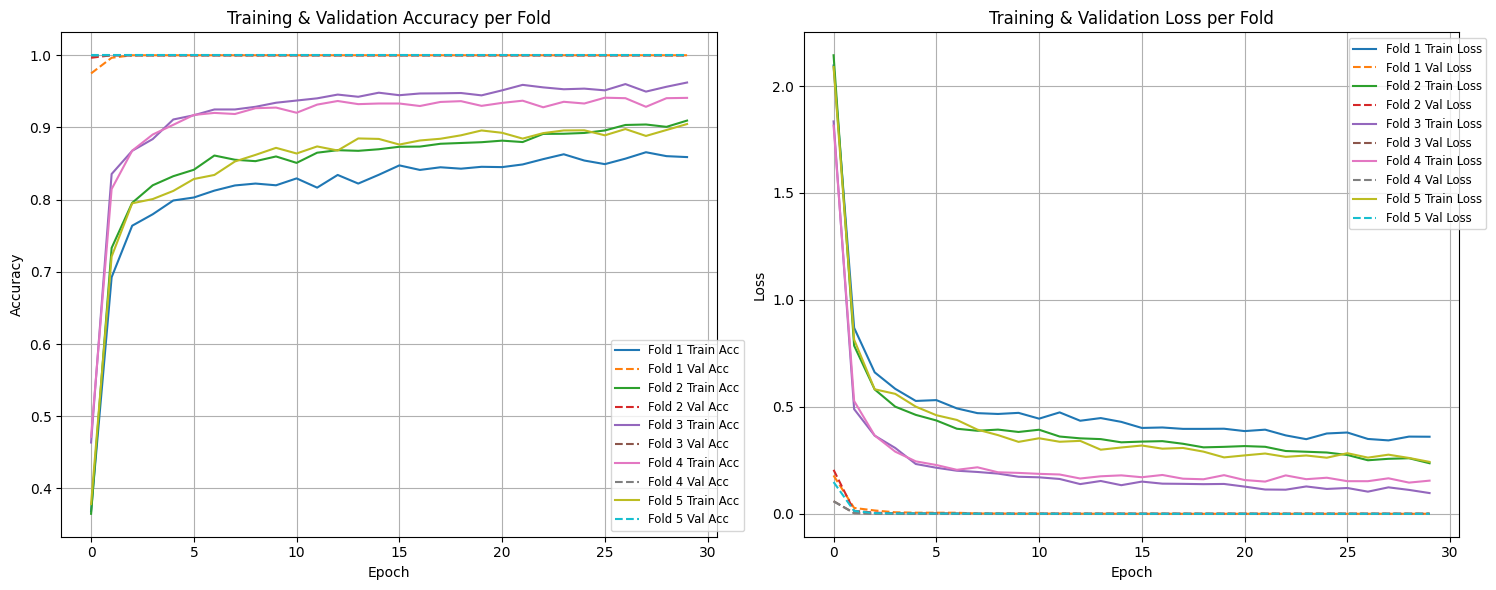

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(15, 6))

# --- Accuracy ---
plt.subplot(1, 2, 1)
for i, history_obj in enumerate(fold_histories):
    plt.plot(history_obj.history['accuracy'],
             label=f'Fold {i+1} Train Acc')
    plt.plot(history_obj.history['val_accuracy'],
             linestyle='--', label=f'Fold {i+1} Val Acc')

plt.title('Training & Validation Accuracy per Fold')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(loc='lower right', bbox_to_anchor=(1.05, 0), fontsize='small')
plt.grid(True)

# --- Loss ---
plt.subplot(1, 2, 2)
for i, history_obj in enumerate(fold_histories):
    plt.plot(history_obj.history['loss'],
             label=f'Fold {i+1} Train Loss')
    plt.plot(history_obj.history['val_loss'],
             linestyle='--', label=f'Fold {i+1} Val Loss')

plt.title('Training & Validation Loss per Fold')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(loc='upper right', bbox_to_anchor=(1.05, 1), fontsize='small')
plt.grid(True)

plt.tight_layout()
plt.show()

### Mean & Std Deviation

In [ ]:
import numpy as np

mean_accuracy = np.mean(fold_accuracies)
std_accuracy  = np.std(fold_accuracies)
mean_loss     = np.mean(fold_losses)
std_loss      = np.std(fold_losses)

print("=" * 45)
print("       K-Fold Cross-Validation Summary")
print("=" * 45)
for i, (acc, loss) in enumerate(zip(fold_accuracies, fold_losses)):
    print(f"  Fold {i+1:>2} — Accuracy: {acc:.4f}  |  Loss: {loss:.4f}")
print("-" * 45)
print(f"  Mean  — Accuracy: {mean_accuracy:.4f}  |  Loss: {mean_loss:.4f}")
print(f"  Std   — Accuracy: {std_accuracy:.4f}  |  Loss: {std_loss:.4f}")
print("=" * 45)

       K-Fold Cross-Validation Summary
  Fold  1 — Accuracy: 1.0000  |  Loss: 0.0001
  Fold  2 — Accuracy: 1.0000  |  Loss: 0.0000
  Fold  3 — Accuracy: 1.0000  |  Loss: 0.0000
  Fold  4 — Accuracy: 1.0000  |  Loss: 0.0000
  Fold  5 — Accuracy: 1.0000  |  Loss: 0.0000
---------------------------------------------
  Mean  — Accuracy: 1.0000  |  Loss: 0.0000
  Std   — Accuracy: 0.0000  |  Loss: 0.0001


In [ ]:
import numpy as np

mean_accuracy = np.mean(fold_accuracies)
std_accuracy  = np.std(fold_accuracies)
mean_loss     = np.mean(fold_losses)
std_loss      = np.std(fold_losses)

print("=" * 45)
print("       K-Fold Cross-Validation Summary")
print("=" * 45)
for i, (acc, loss) in enumerate(zip(fold_accuracies, fold_losses)):
    print(f"  Fold {i+1:>2} — Accuracy: {acc:.4f}  |  Loss: {loss:.4f}")
print("-" * 45)
print(f"  Mean  — Accuracy: {mean_accuracy:.4f}  |  Loss: {mean_loss:.4f}")
print(f"  Std   — Accuracy: {std_accuracy:.4f}  |  Loss: {std_loss:.4f}")
print("=" * 45)

       K-Fold Cross-Validation Summary
  Fold  1 — Accuracy: 1.0000  |  Loss: 0.0001
  Fold  2 — Accuracy: 1.0000  |  Loss: 0.0000
  Fold  3 — Accuracy: 1.0000  |  Loss: 0.0000
  Fold  4 — Accuracy: 1.0000  |  Loss: 0.0000
  Fold  5 — Accuracy: 1.0000  |  Loss: 0.0000
---------------------------------------------
  Mean  — Accuracy: 1.0000  |  Loss: 0.0000
  Std   — Accuracy: 0.0000  |  Loss: 0.0001


In [ ]:
import numpy as np

mean_accuracy = np.mean(fold_accuracies)
std_accuracy  = np.std(fold_accuracies)
mean_loss     = np.mean(fold_losses)
std_loss      = np.std(fold_losses)

print("=" * 45)
print("       K-Fold Cross-Validation Summary")
print("=" * 45)
for i, (acc, loss) in enumerate(zip(fold_accuracies, fold_losses)):
    print(f"  Fold {i+1:>2} — Accuracy: {acc:.4f}  |  Loss: {loss:.4f}")
print("-" * 45)
print(f"  Mean  — Accuracy: {mean_accuracy:.4f}  |  Loss: {mean_loss:.4f}")
print(f"  Std   — Accuracy: {std_accuracy:.4f}  |  Loss: {std_loss:.4f}")
print("=" * 45)

       K-Fold Cross-Validation Summary
  Fold  1 — Accuracy: 1.0000  |  Loss: 0.0001
  Fold  2 — Accuracy: 1.0000  |  Loss: 0.0000
  Fold  3 — Accuracy: 1.0000  |  Loss: 0.0000
  Fold  4 — Accuracy: 1.0000  |  Loss: 0.0000
  Fold  5 — Accuracy: 1.0000  |  Loss: 0.0000
---------------------------------------------
  Mean  — Accuracy: 1.0000  |  Loss: 0.0000
  Std   — Accuracy: 0.0000  |  Loss: 0.0001


## Stratified K-Fold

### Train

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedKFold

# Instantiate KFold
skf = StratifiedKFold(n_splits=KFOLD_N_SPLITS, shuffle=True, random_state=KFOLD_RANDOM_STATE)

# Initialize lists to store performance metrics for each fold
sfold_accuracies = []
sfold_losses = []
sfold_histories = []

for fold, (train_val_index, test_index) in enumerate(skf.split(features, encoded_labels)):
    print(f"\n--- Fold {fold+1}/{skf.n_splits} ---")

    # Split train_val_index
    train_index, val_index = train_test_split(
        train_val_index,
        test_size=KFOLD_TEST_SIZE,
        random_state=KFOLD_RANDOM_STATE,
        stratify=encoded_labels[train_val_index]  # preserve class distribution
    )

    X_train_fold = np.expand_dims(features[train_index], axis=-1)
    X_val_fold   = np.expand_dims(features[val_index],   axis=-1)
    X_test_fold  = np.expand_dims(features[test_index],  axis=-1)

    y_train_fold = categorical_labels[train_index]
    y_val_fold   = categorical_labels[val_index]
    y_test_fold  = categorical_labels[test_index]

    model = create_cnn_model(input_shape, num_classes)

    print(f"Training model for Fold {fold+1}...")
    history = model.fit(
        X_train_fold, y_train_fold,
        epochs=KFOLD_EPOCHS,
        batch_size=KFOLD_BATCH_SIZE,
        validation_data=(X_val_fold, y_val_fold),  # enables val metrics per epoch
        validation_split=KFOLD_VALIDATION_SPLIT,
        verbose=0
    )
    sfold_histories.append(history)

    print(f"Evaluating model for Fold {fold+1}...")
    loss, accuracy = model.evaluate(X_test_fold, y_test_fold, verbose=0)

    sfold_accuracies.append(accuracy)
    sfold_losses.append(loss)
    print(f"Fold {fold+1} - Test Accuracy: {accuracy:.4f}, Test Loss: {loss:.4f}")

print("\nStratified K-Fold Cross-Validation complete.")


--- Fold 1/5 ---
Training model for Fold 1...
Evaluating model for Fold 1...
Fold 1 - Test Accuracy: 1.0000, Test Loss: 0.0006

--- Fold 2/5 ---
Training model for Fold 2...
Evaluating model for Fold 2...
Fold 2 - Test Accuracy: 1.0000, Test Loss: 0.0000

--- Fold 3/5 ---
Training model for Fold 3...
Evaluating model for Fold 3...
Fold 3 - Test Accuracy: 1.0000, Test Loss: 0.0000

--- Fold 4/5 ---
Training model for Fold 4...
Evaluating model for Fold 4...
Fold 4 - Test Accuracy: 1.0000, Test Loss: 0.0001

--- Fold 5/5 ---
Training model for Fold 5...
Evaluating model for Fold 5...
Fold 5 - Test Accuracy: 1.0000, Test Loss: 0.0000

Stratified K-Fold Cross-Validation complete.


### Show class distribution

In [ ]:
from collections import Counter
import numpy as np

print("=" * 65)
print("              Class Distribution per Fold")
print("=" * 65)

for fold, (train_val_index, test_index) in enumerate(skf.split(features, encoded_labels)):
    train_index, val_index = train_test_split(
        train_val_index,
        test_size=KFOLD_TEST_SIZE,
        random_state=KFOLD_RANDOM_STATE,
        stratify=encoded_labels[train_val_index]
    )

    train_dist = Counter(encoded_labels[train_index])
    val_dist   = Counter(encoded_labels[val_index])
    test_dist  = Counter(encoded_labels[test_index])

    classes = sorted(train_dist.keys())
    class_names = label_encoder.inverse_transform(classes)

    print(f"\n  Fold {fold+1}")
    print(f"  {'Class':<20} {'Train':>8} {'Val':>8} {'Test':>8}  {'Total':>8}")
    print(f"  {'-'*20} {'-'*8} {'-'*8} {'-'*8}  {'-'*8}")

    for cls, name in zip(classes, class_names):
        tr = train_dist.get(cls, 0)
        vl = val_dist.get(cls, 0)
        te = test_dist.get(cls, 0)
        print(f"  {str(name):<20} {tr:>8} {vl:>8} {te:>8}  {tr+vl+te:>8}")

    print(f"  {'TOTAL':<20} {sum(train_dist.values()):>8} {sum(val_dist.values()):>8} {sum(test_dist.values()):>8}  {len(encoded_labels):>8}")

print("\n" + "=" * 65)

              Class Distribution per Fold

  Fold 1
  Class                   Train      Val     Test     Total
  -------------------- -------- -------- --------  --------
  A#_diminished_4           128       32       40       200
  A#_major_4                128       32       40       200
  A#_minor_4                128       32       40       200
  A_diminished_4            128       32       40       200
  A_major_4                 128       32       40       200
  A_minor_4                 128       32       40       200
  B_diminished_4            128       32       40       200
  B_major_4                 128       32       40       200
  B_minor_4                 128       32       40       200
  C#_diminished_4           128       32       40       200
  C#_major_4                128       32       40       200
  C#_minor_4                128       32       40       200
  C_diminished_4            128       32       40       200
  C_major_4                 128       32       4

### Accuracy & Loss Plot

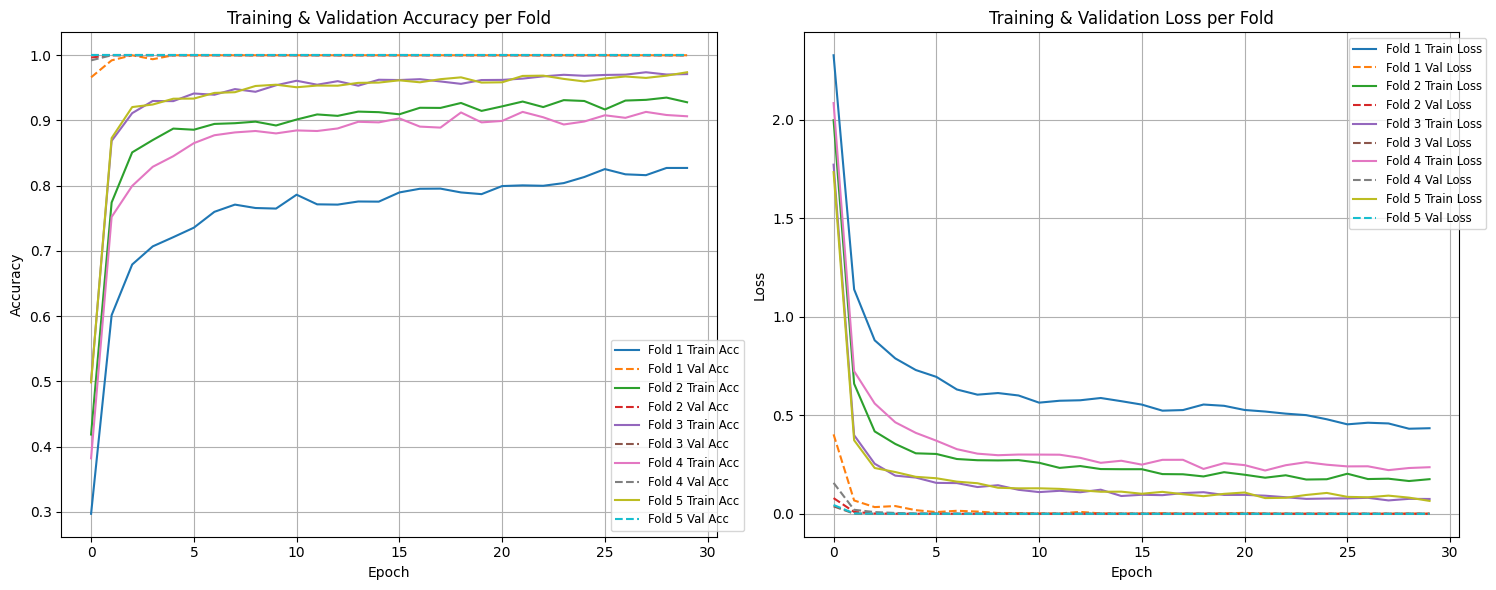

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(15, 6))

# --- Accuracy ---
plt.subplot(1, 2, 1)
for i, history_obj in enumerate(sfold_histories):
    plt.plot(history_obj.history['accuracy'],
             label=f'Fold {i+1} Train Acc')
    plt.plot(history_obj.history['val_accuracy'],
             linestyle='--', label=f'Fold {i+1} Val Acc')

plt.title('Training & Validation Accuracy per Fold')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(loc='lower right', bbox_to_anchor=(1.05, 0), fontsize='small')
plt.grid(True)

# --- Loss ---
plt.subplot(1, 2, 2)
for i, history_obj in enumerate(sfold_histories):
    plt.plot(history_obj.history['loss'],
             label=f'Fold {i+1} Train Loss')
    plt.plot(history_obj.history['val_loss'],
             linestyle='--', label=f'Fold {i+1} Val Loss')

plt.title('Training & Validation Loss per Fold')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(loc='upper right', bbox_to_anchor=(1.05, 1), fontsize='small')
plt.grid(True)

plt.tight_layout()
plt.show()

### Mean & Std Deviation

In [ ]:
import numpy as np

mean_accuracy = np.mean(sfold_accuracies)
std_accuracy  = np.std(sfold_accuracies)
mean_loss     = np.mean(sfold_losses)
std_loss      = np.std(sfold_losses)

print("=" * 45)
print("Stratified K-Fold Cross-Validation Summary")
print("=" * 45)
for i, (acc, loss) in enumerate(zip(fold_accuracies, fold_losses)):
    print(f"  Fold {i+1:>2} — Accuracy: {acc:.4f}  |  Loss: {loss:.4f}")
print("-" * 45)
print(f"  Mean  — Accuracy: {mean_accuracy:.4f}  |  Loss: {mean_loss:.4f}")
print(f"  Std   — Accuracy: {std_accuracy:.4f}  |  Loss: {std_loss:.4f}")
print("=" * 45)

Stratified K-Fold Cross-Validation Summary
  Fold  1 — Accuracy: 1.0000  |  Loss: 0.0001
  Fold  2 — Accuracy: 1.0000  |  Loss: 0.0000
  Fold  3 — Accuracy: 1.0000  |  Loss: 0.0000
  Fold  4 — Accuracy: 1.0000  |  Loss: 0.0000
  Fold  5 — Accuracy: 1.0000  |  Loss: 0.0000
---------------------------------------------
  Mean  — Accuracy: 1.0000  |  Loss: 0.0001
  Std   — Accuracy: 0.0000  |  Loss: 0.0003


# SVM model

## Prepare data

In [ ]:
SVM_RANDOM_STATE = 42
SVM_TEST_SIZE = 0.1
SVM_CV_FOLDS = 5

In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Flatten 2D CQT features to 1D for SVM input
features_flat = features.reshape(features.shape[0], -1)

# Encode labels
svm_label_encoder = LabelEncoder()
svm_encoded_labels = svm_label_encoder.fit_transform(labels)

# Scale features
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features_flat)

# Train/test split
X_svm_train, X_svm_test, y_svm_train, y_svm_test = train_test_split(
    features_scaled,
    svm_encoded_labels,
    test_size=SVM_TEST_SIZE,
    random_state=SVM_RANDOM_STATE,
    stratify=svm_encoded_labels
)

print(f"X_svm_train shape: {X_svm_train.shape}")
print(f"X_svm_test shape:  {X_svm_test.shape}")
print(f"Number of classes: {len(svm_label_encoder.classes_)}")

X_svm_train shape: (6480, 7200)
X_svm_test shape:  (720, 7200)
Number of classes: 36


## Single model

### Train model

In [ ]:
from sklearn.svm import SVC

svm_model = SVC(kernel='rbf', C=10, gamma='scale', random_state=SVM_RANDOM_STATE)

print("Training SVM model...")
svm_model.fit(X_svm_train, y_svm_train)
print("Training complete.")

Training SVM model...
Training complete.


### Evaluate model

In [ ]:
from sklearn.metrics import accuracy_score, classification_report

y_svm_pred = svm_model.predict(X_svm_test)

svm_accuracy = accuracy_score(y_svm_test, y_svm_pred)
print(f"Test Accuracy: {svm_accuracy:.4f}")

svm_class_labels = svm_label_encoder.classes_
report = classification_report(y_svm_test, y_svm_pred, target_names=svm_class_labels)
print("\nClassification Report:\n", report)

Test Accuracy: 1.0000

Classification Report:
                  precision    recall  f1-score   support

A#_diminished_4       1.00      1.00      1.00        20
     A#_major_4       1.00      1.00      1.00        20
     A#_minor_4       1.00      1.00      1.00        20
 A_diminished_4       1.00      1.00      1.00        20
      A_major_4       1.00      1.00      1.00        20
      A_minor_4       1.00      1.00      1.00        20
 B_diminished_4       1.00      1.00      1.00        20
      B_major_4       1.00      1.00      1.00        20
      B_minor_4       1.00      1.00      1.00        20
C#_diminished_4       1.00      1.00      1.00        20
     C#_major_4       1.00      1.00      1.00        20
     C#_minor_4       1.00      1.00      1.00        20
 C_diminished_4       1.00      1.00      1.00        20
      C_major_4       1.00      1.00      1.00        20
      C_minor_4       1.00      1.00      1.00        20
D#_diminished_4       1.00      1.00    

### Confusion Matrix

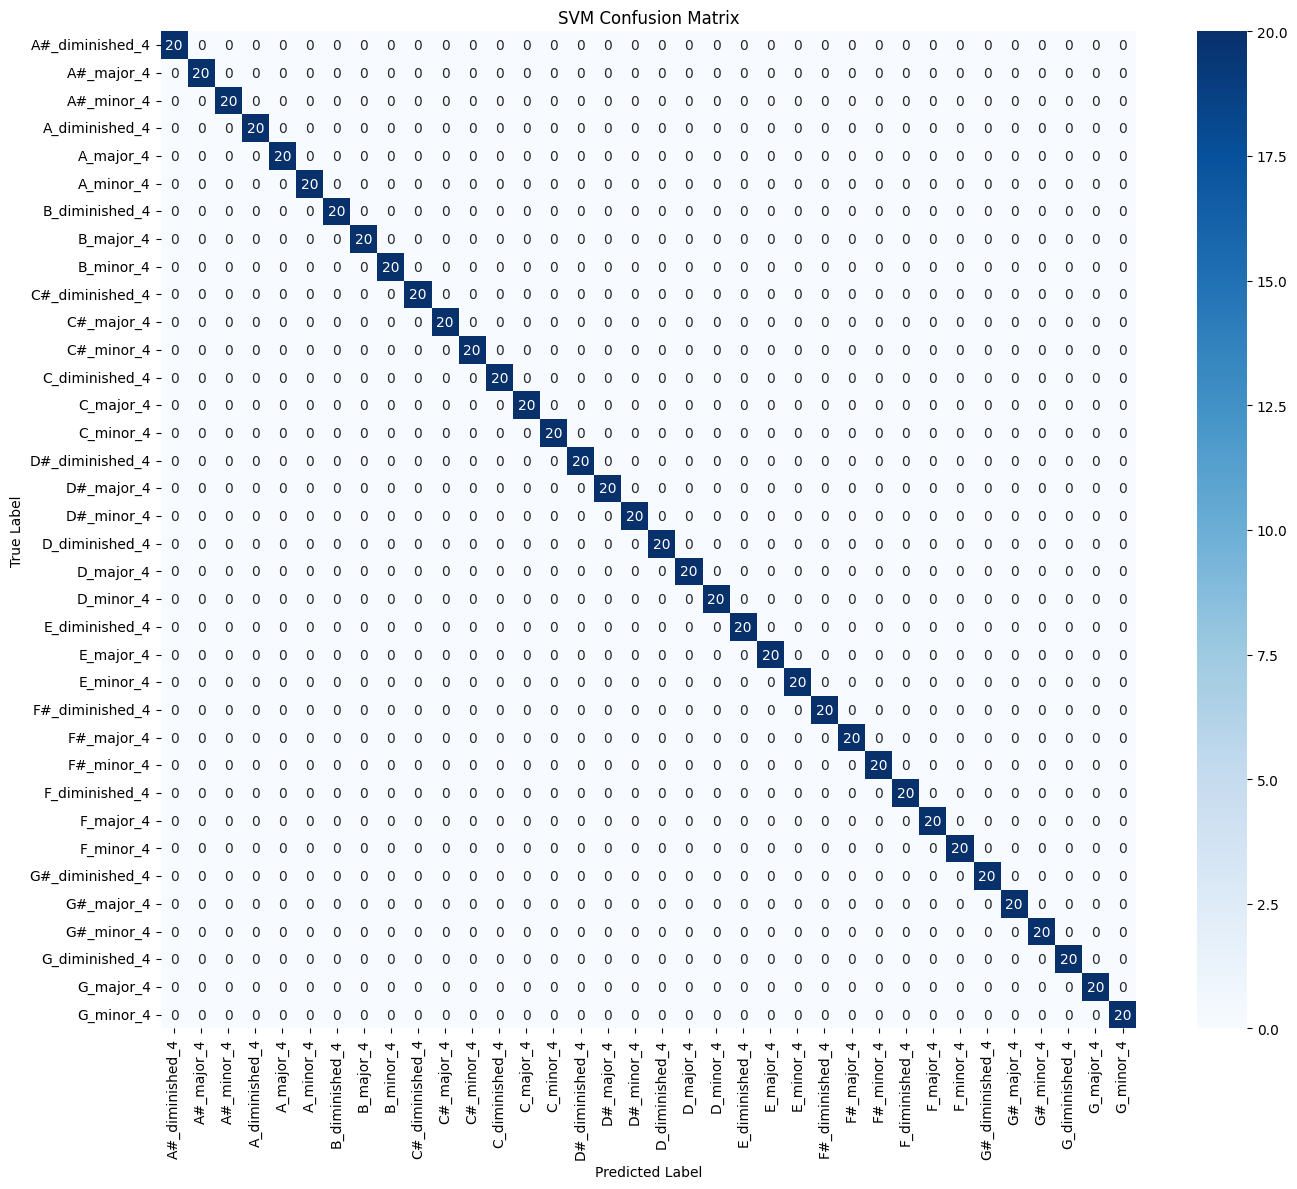

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm_svm = confusion_matrix(y_svm_test, y_svm_pred)

plt.figure(figsize=(14, 12))
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Blues',
            xticklabels=svm_class_labels, yticklabels=svm_class_labels)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('SVM Confusion Matrix')
plt.tight_layout()
plt.show()

### Save SVM Model

In [ ]:
import joblib

joblib.dump(svm_model, svm_model_path)
joblib.dump(scaler, svm_scaler_path)
joblib.dump(svm_label_encoder, svm_encoder_path)

print(f"SVM model saved to {svm_model_dir}")

SVM model saved to ./models/svm_model


## Hyperparameter tuning

### Grid Search CV

In [ ]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.svm import SVC

param_grid = {
    'kernel': ['rbf'],
    'C':      [0.1, 1000],
    'gamma':  [0.1, 0.9],
}

cv = StratifiedKFold(n_splits=SVM_CV_FOLDS, shuffle=True, random_state=SVM_RANDOM_STATE)

grid_search = GridSearchCV(
    SVC(random_state=SVM_RANDOM_STATE),
    param_grid,
    cv=cv,
    scoring='accuracy',
    n_jobs=-1,
    verbose=3,
)

print("Running GridSearchCV...")
grid_search.fit(X_svm_train, y_svm_train)
print("Done.")

Running GridSearchCV...
Fitting 5 folds for each of 4 candidates, totalling 20 fits


KeyboardInterrupt: 

### Best parameters

In [ ]:
import pandas as pd

cv_results = pd.DataFrame(grid_search.cv_results_)
cv_results_sorted = cv_results.sort_values('rank_test_score')[
    ['rank_test_score', 'param_C', 'param_kernel', 'param_gamma',
     'mean_test_score', 'std_test_score']
].rename(columns={
    'rank_test_score': 'Rank',
    'param_C': 'C',
    'param_kernel': 'Kernel',
    'param_gamma': 'Gamma',
    'mean_test_score': 'Mean CV Accuracy',
    'std_test_score': 'Std CV Accuracy',
})

cv_results_sorted.head(10)

In [ ]:
print(f"Best parameters: {grid_search.best_params_}")
print(f"Best CV accuracy: {grid_search.best_score_:.4f}")

best_svm_model = grid_search.best_estimator_

### Evaluate best model

In [ ]:
from sklearn.metrics import accuracy_score, classification_report

y_gs_pred = best_svm_model.predict(X_svm_test)

gs_accuracy = accuracy_score(y_svm_test, y_gs_pred)
print(f"Test Accuracy (best model): {gs_accuracy:.4f}")

svm_class_labels = svm_label_encoder.classes_
report_gs = classification_report(y_svm_test, y_gs_pred, target_names=svm_class_labels)
print("\nClassification Report:\n", report_gs)

### Confusion Matrix

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm_gs = confusion_matrix(y_svm_test, y_gs_pred)

plt.figure(figsize=(14, 12))
sns.heatmap(cm_gs, annot=True, fmt='d', cmap='Blues',
            xticklabels=svm_class_labels, yticklabels=svm_class_labels)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title(f'SVM (GridSearchCV) Confusion Matrix\n{grid_search.best_params_}')
plt.tight_layout()
plt.show()

# Noisy Dataset Test (TODO)

## Load noisy features

In [ ]:
import numpy as np
import os

# Define the path to the .npz file
noisy_save_path = features_path_noisy

# Sample rate 48 khz * 2 seconds / 512 default hop size = 187.5
max_cqt_pad_len = 200

noisy_features = []
noisy_labels = []

def preprocess(cqt):
  if cqt.shape[1] < max_cqt_pad_len:
      pad_width = max_cqt_pad_len - cqt.shape[1]
      cqt = np.pad(cqt, pad_width=((0, 0), (0, pad_width)), mode='constant')
  else:
      cqt = cqt[:, :max_cqt_pad_len]
  return cqt

if os.path.exists(noisy_save_path):
  print(f"Loading features and labels from {noisy_save_path}")
  data = np.load(noisy_save_path)
  noisy_features = np.array([preprocess(f) for f in data['features']])
  noisy_labels = data['labels']
  print("Features and labels loaded successfully.")
else:
  print(f"Features and labels not found at {noisy_save_path}")

Loading features and labels from ./datasets/features-noisy.npz
Features and labels loaded successfully.


## Test CNN model

### Load model

In [ ]:
import tensorflow as tf

clean_model_path = cnn_model_path_clean
clean_loaded_model = tf.keras.models.load_model(clean_model_path + '.h5')

### Test CNN model

113/113 [==============================] - 1s 5ms/step


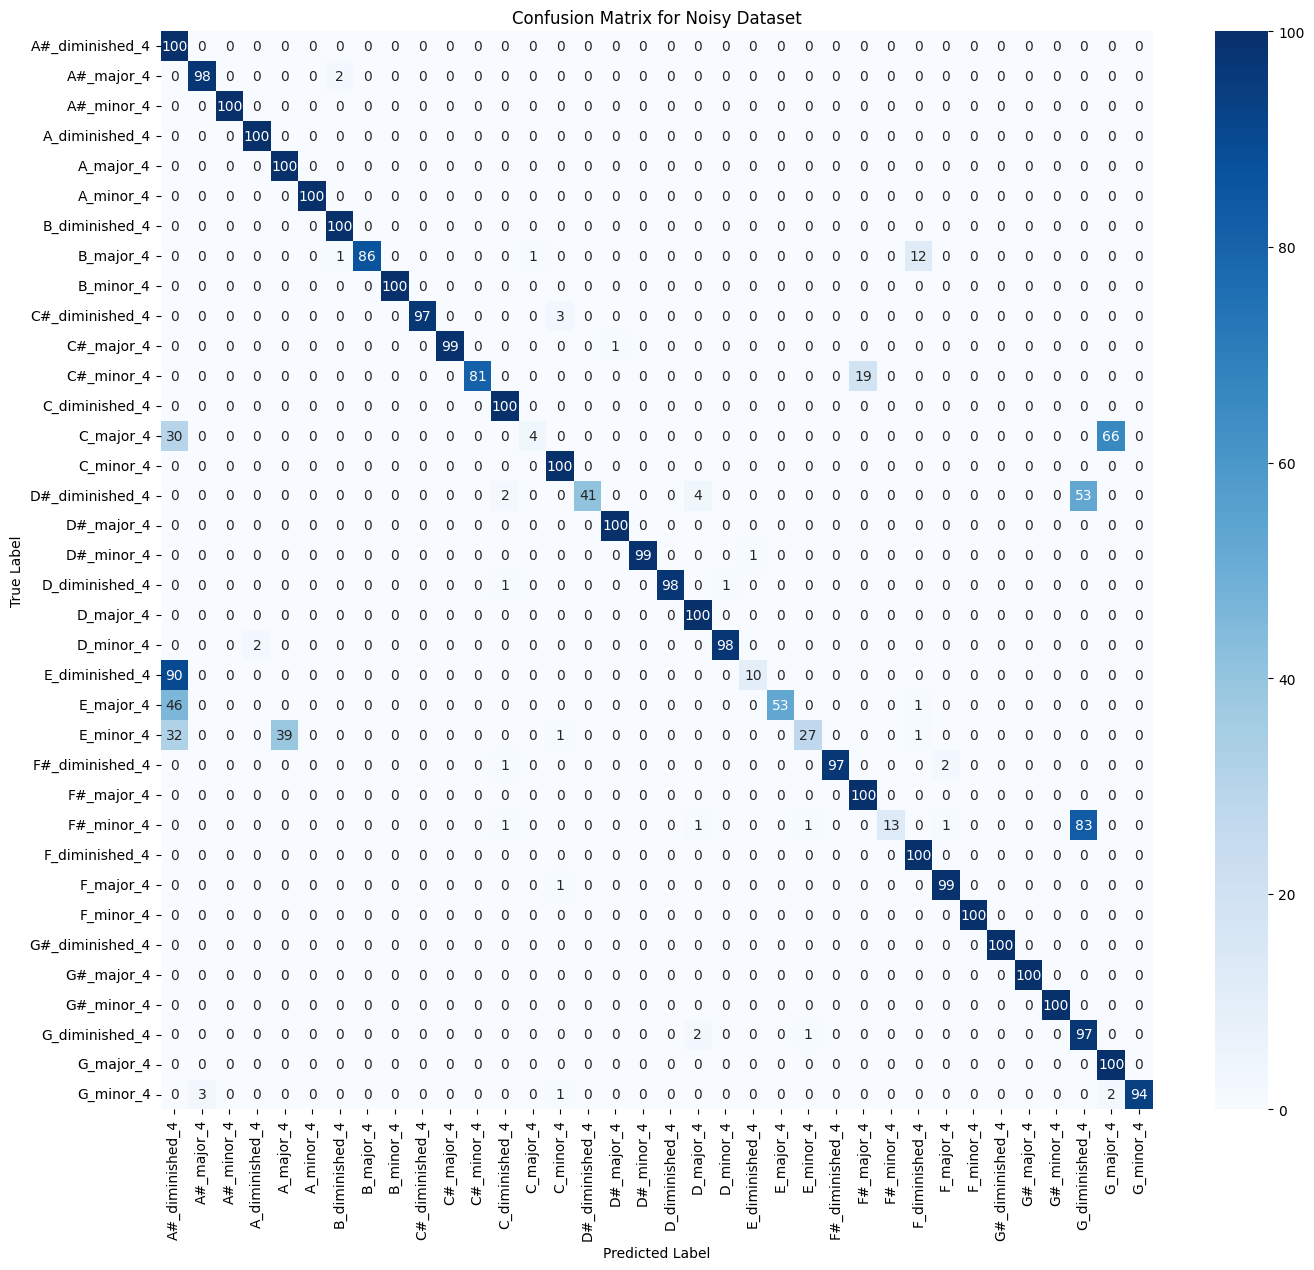


Classification Report for Noisy Dataset:
                  precision    recall  f1-score   support

A#_diminished_4       0.34      1.00      0.50       100
     A#_major_4       0.97      0.98      0.98       100
     A#_minor_4       1.00      1.00      1.00       100
 A_diminished_4       0.98      1.00      0.99       100
      A_major_4       0.72      1.00      0.84       100
      A_minor_4       1.00      1.00      1.00       100
 B_diminished_4       0.97      1.00      0.99       100
      B_major_4       1.00      0.86      0.92       100
      B_minor_4       1.00      1.00      1.00       100
C#_diminished_4       1.00      0.97      0.98       100
     C#_major_4       1.00      0.99      0.99       100
     C#_minor_4       1.00      0.81      0.90       100
 C_diminished_4       0.95      1.00      0.98       100
      C_major_4       0.80      0.04      0.08       100
      C_minor_4       0.94      1.00      0.97       100
D#_diminished_4       1.00      0.41      0.

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from keras.utils import to_categorical
from sklearn.preprocessing import LabelEncoder

# Fit label encoder on clean labels (all classes the model was trained on)
noisy_label_encoder = LabelEncoder()
noisy_label_encoder.fit(noisy_labels)
num_classes = len(noisy_label_encoder.classes_)

# Encode noisy labels using the clean label encoder
noisy_encoded_labels = noisy_label_encoder.transform(noisy_labels)
noisy_categorical_labels = to_categorical(noisy_encoded_labels, num_classes=num_classes)

# Reshape noisy_features to add a channel dimension
noisy_features_reshaped = np.expand_dims(noisy_features, axis=-1)

# Get predictions for the noisy test set
noisy_predictions = clean_loaded_model.predict(noisy_features_reshaped)
predicted_noisy_classes = np.argmax(noisy_predictions, axis=1)
actual_noisy_classes = np.argmax(noisy_categorical_labels, axis=1)

# Get class labels from the label encoder
class_labels = noisy_label_encoder.classes_

# Compute the confusion matrix
cm_noisy = confusion_matrix(actual_noisy_classes, predicted_noisy_classes)

# Plot the confusion matrix
plt.figure(figsize=(16, 14))
sns.heatmap(cm_noisy, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for Noisy Dataset')
plt.show()

# Generate classification report
report_noisy = classification_report(actual_noisy_classes, predicted_noisy_classes, target_names=class_labels)
print("\nClassification Report for Noisy Dataset:\n", report_noisy)

## Test SVM model

### Load Model

In [ ]:
import joblib

svm_model = joblib.load(svm_model_path)
scaler = joblib.load(svm_scaler_path)
svm_label_encoder = joblib.load(svm_encoder_path)

print(f"SVM model loaded from {svm_model_dir}")
print(f"Classes: {svm_label_encoder.classes_}")

SVM model loaded from ./models/svm_model
Classes: ['A#_diminished_4' 'A#_major_4' 'A#_minor_4' 'A_diminished_4' 'A_major_4'
 'A_minor_4' 'B_diminished_4' 'B_major_4' 'B_minor_4' 'C#_diminished_4'
 'C#_major_4' 'C#_minor_4' 'C_diminished_4' 'C_major_4' 'C_minor_4'
 'D#_diminished_4' 'D#_major_4' 'D#_minor_4' 'D_diminished_4' 'D_major_4'
 'D_minor_4' 'E_diminished_4' 'E_major_4' 'E_minor_4' 'F#_diminished_4'
 'F#_major_4' 'F#_minor_4' 'F_diminished_4' 'F_major_4' 'F_minor_4'
 'G#_diminished_4' 'G#_major_4' 'G#_minor_4' 'G_diminished_4' 'G_major_4'
 'G_minor_4']


### Test SVM Model

SVM Test Accuracy on Noisy Dataset: 0.0289

Classification Report:
                  precision    recall  f1-score   support

A#_diminished_4       1.00      0.01      0.02       100
     A#_major_4       0.00      0.00      0.00       100
     A#_minor_4       0.00      0.00      0.00       100
 A_diminished_4       0.00      0.00      0.00       100
      A_major_4       0.00      0.00      0.00       100
      A_minor_4       0.02      0.15      0.03       100
 B_diminished_4       0.00      0.00      0.00       100
      B_major_4       0.00      0.00      0.00       100
      B_minor_4       0.00      0.00      0.00       100
C#_diminished_4       0.00      0.00      0.00       100
     C#_major_4       0.00      0.00      0.00       100
     C#_minor_4       0.00      0.00      0.00       100
 C_diminished_4       0.03      0.88      0.06       100
      C_major_4       0.00      0.00      0.00       100
      C_minor_4       0.00      0.00      0.00       100
D#_diminished_4    

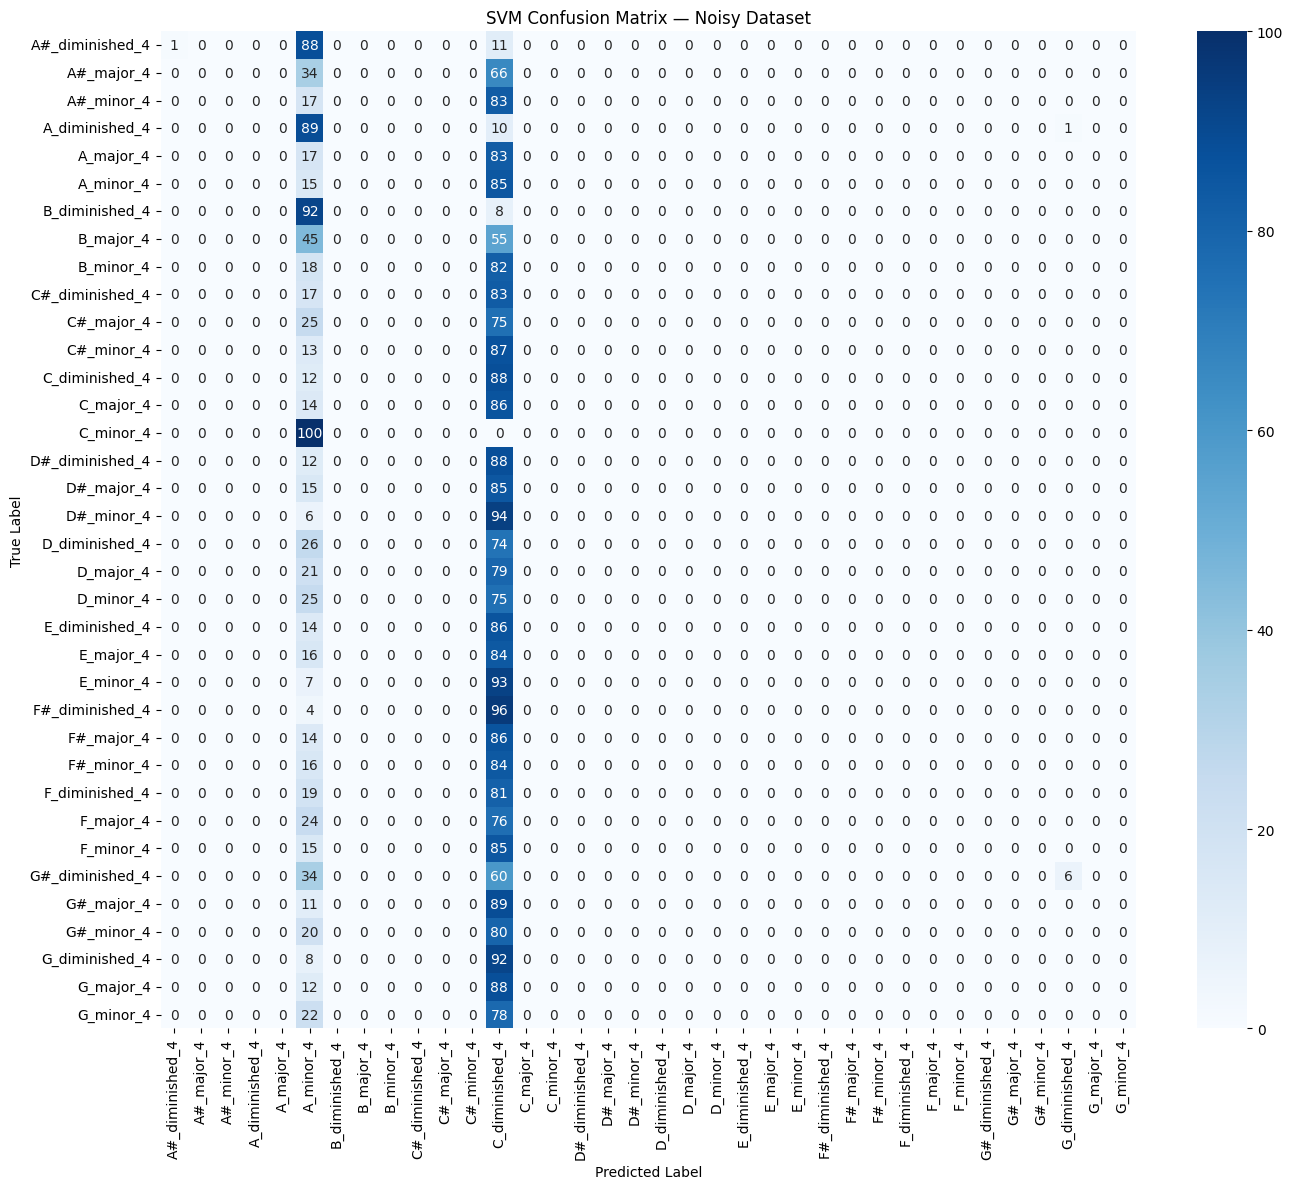

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# Flatten and scale noisy features the same way as training data
noisy_features_flat   = noisy_features.reshape(noisy_features.shape[0], -1)
noisy_features_scaled = scaler.transform(noisy_features_flat)

# Encode noisy labels using the loaded label encoder
noisy_svm_encoded = svm_label_encoder.transform(noisy_labels)

# Predict
y_noisy_pred = svm_model.predict(noisy_features_scaled)

# Accuracy & report
noisy_svm_accuracy = accuracy_score(noisy_svm_encoded, y_noisy_pred)
print(f"SVM Test Accuracy on Noisy Dataset: {noisy_svm_accuracy:.4f}")

svm_class_labels = svm_label_encoder.classes_
report_noisy_svm = classification_report(noisy_svm_encoded, y_noisy_pred, target_names=svm_class_labels)
print("\nClassification Report:\n", report_noisy_svm)

# Confusion matrix
cm_noisy_svm = confusion_matrix(noisy_svm_encoded, y_noisy_pred)

plt.figure(figsize=(14, 12))
sns.heatmap(cm_noisy_svm, annot=True, fmt='d', cmap='Blues',
            xticklabels=svm_class_labels, yticklabels=svm_class_labels)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('SVM Confusion Matrix — Noisy Dataset')
plt.tight_layout()
plt.show()

## Noise reduction to features

## Test with reduced noise